In [1]:
import numpy as np
import pandas as pd
import cooler
from cooltools.lib.numutils import observed_over_expected, adaptive_coarsegrain
from cooltools.lib.numutils import interpolate_bad_singletons, set_diag, interp_nan
from astropy.convolution import Gaussian2DKernel
from astropy.convolution import convolve
from bioframe.io.fileops import read_bigwig

In [2]:
import torch

In [3]:
from pyfaidx import Fasta

In [4]:
FASTA_FILE = "/project/fudenber_735/genomes/mm10/mm10.fa"
BED_FILE = "/project/fudenber_735/tensorflow_models/akita/v2/data/mm10/sequences.bed"
COOL_FILE = "/project/fudenber_735/GEO/Hsieh2019/4DN/mESC_mm10_4DNFILZ1CPT8.mapq_30.2048.cool"
OUTPUT_DIR = "/scratch1/smaruj/train_pytorch_akita/mouse"
FOLD = 0

# --- Load Data ---
genome = Fasta(FASTA_FILE)
df = pd.read_csv(BED_FILE, sep="\t", header=None, names=["chrom", "start", "end", "fold"])
df_select_fold = df[df["fold"] == f"fold{FOLD}"].reset_index(drop=True)

genome_hic_cool = cooler.Cooler(COOL_FILE)

In [ ]:
import bioframe

In [ ]:
# mm10_chromsizes = bioframe.fetch_chromsizes('mm10')

In [ ]:
import cooltools

In [ ]:
# expected = cooltools.expected_cis(genome_hic_cool, view_df=None)

In [5]:
import matplotlib.pyplot as plt

In [ ]:
chr1 = expected[expected["region1"] == "chr1"]

In [ ]:
chr2 = expected[expected["region1"] == "chr2"]

In [ ]:
# Plot the expected contact decay curve
plt.figure(figsize=(8, 6))
# for chrom, df in expected.groupby("chrom"):
#     plt.loglog(df["dist"], df["balanced.avg"], label=chrom, alpha=0.6)

plt.loglog(chr1["dist"], chr1["balanced.avg"], alpha=0.6, label="chr1")
plt.loglog(chr2["dist"], chr2["balanced.avg"], alpha=0.6, label="chr2")

plt.xlabel("Genomic distance (bp)")
plt.ylabel("Expected contact frequency")
plt.title("Expected cis contacts decay")
plt.legend(ncol=2, fontsize=8)
plt.grid(True, which="both", linestyle="--", alpha=0.5)

# Show the plot
plt.show()

In [ ]:
# Plot the expected contact decay curve
plt.figure(figsize=(8, 6))
# for chrom, df in expected.groupby("chrom"):
#     plt.loglog(df["dist"], df["balanced.avg"], label=chrom, alpha=0.6)

plt.loglog(chr1["dist"][2:], chr1["balanced.avg.smoothed.agg"][2:], label="chr1")
plt.loglog(chr2["dist"][2:], chr2["balanced.avg.smoothed.agg"][2:], label="chr2")

plt.xlabel("Genomic distance (bp)")
plt.ylabel("Expected contact frequency")
plt.title("Expected cis contacts decay")
plt.legend(ncol=2, fontsize=8)
plt.grid(True, which="both", linestyle="--", alpha=0.5)

# Show the plot
plt.show()

In [ ]:
# expected.to_csv("/project/fudenber_735/GEO/Hsieh2019/4DN/mESC_mm10_4DNFILZ1CPT8.mapq_30.2048.expected", index=False)

In [6]:
expected = pd.read_csv("/project/fudenber_735/GEO/Hsieh2019/4DN/mESC_mm10_4DNFILZ1CPT8.mapq_30.2048.expected")

In [7]:
# low_q_df = pd.read_csv("/project/fudenber_735/backup/DNN_HiC/data_mm10/mm10_gaps.bed", sep="\t", names=["chr", "start", "end"])
low_q_df = pd.read_csv("/project/fudenber_735/backup/DNN_HiC/data_mm10/mm10.blacklist.rep.bed", sep="\t", names=["chr", "start", "end"])

In [ ]:
low_q_df

In [8]:
import random

def one_hot_encode_sequence(sequence_obj):
    sequence = str(sequence_obj).upper()
    base_to_int = {'A': 0, 'C': 1, 'G': 2, 'T': 3}

    encoded_sequence = np.array([
        base_to_int.get(base, base_to_int[random.choice("ACGT")]) for base in sequence
    ])

    one_hot_encoded = np.zeros((4, len(encoded_sequence)), dtype=np.float32)
    one_hot_encoded[encoded_sequence, np.arange(len(encoded_sequence))] = 1

    return np.expand_dims(one_hot_encoded, axis=0)


In [9]:
import re

def extract_coordinates_from_mseq(mseq_str):
    # Regular expression to match the format: chrom:start-end
    match = re.match(r"(?P<chrom>\w+):(?P<start>\d+)-(?P<end>\d+)", mseq_str)
    
    if match:
        chrom = match.group('chrom')
        start = int(match.group('start'))
        end = int(match.group('end'))
        return chrom, start, end
    else:
        raise ValueError(f"Invalid mseq_str format: {mseq_str}")

In [ ]:
from scipy.ndimage import generic_filter

def fill_nan_nearest(matrix):
    """Fill NaNs with the nearest non-NaN value using a moving window."""
    nan_mask = np.isnan(matrix)
    
    # Function to apply within each window
    def filter_fn(window):
        if np.all(np.isnan(window)):  # If the entire window is NaN, return NaN
            return np.nan
        else:
            # return np.nanmedian(window)  # Use median of valid values within window
            return np.nanmax(window)

    # Apply the filter to the matrix
    filled_matrix = generic_filter(matrix, filter_fn, size=3, mode='nearest')

    # Replace NaNs with the filtered result
    matrix[nan_mask] = filled_matrix[nan_mask]
    return matrix

In [10]:
def process_hic_matrix(genome_hic_cool, mseq_str, diagonal_offset=2, padding=32, kernel_stddev=1, bin_size=2048, gaps_df=None):
    seq_hic_raw = genome_hic_cool.matrix(balance=True).fetch(mseq_str)
    
    chrom, start, end = extract_coordinates_from_mseq(mseq_str)
    
    # Check for NaN filtering percentage
    seq_hic_nan = np.isnan(seq_hic_raw)
    num_filtered_bins = np.sum(np.sum(seq_hic_nan, axis=0) == len(seq_hic_nan))
    print("num_filtered_bins:", num_filtered_bins)
    
    if num_filtered_bins > (0.5 * len(seq_hic_nan)):
        print(f"More than 50% bins filtered in {mseq_str}. Check Hi-C data quality.")
    
    ###########
    # Mask for rows/columns full of NaNs
    row_nan_mask = np.all(seq_hic_nan, axis=1)  # Rows with all NaNs
    col_nan_mask = np.all(seq_hic_nan, axis=0)  # Columns with all NaNs
    
    true_row_indices = np.where(row_nan_mask)[0]
    print(f"Indices of rows with NaNs: {true_row_indices}")
    
    # Apply the NaN mask earlier in the process to avoid processing NaN-only rows/columns
    seq_hic_raw[row_nan_mask, :] = np.nan  # Mask entire rows
    seq_hic_raw[:, col_nan_mask] = np.nan  # Mask entire columns
    
    # Check for NaN filtering percentage
    num_filtered_bins = np.sum(np.sum(seq_hic_nan, axis=0) == len(seq_hic_nan))
    print("num_filtered_bins:", num_filtered_bins)
    ###########
    
    # Mask for regions overlapping with gaps
    if gaps_df is not None:
        # Filter gaps_df for the current chromosome
        gaps_chr = gaps_df[gaps_df['chr'] == chrom]
        
        # Iterate through each gap region and mark the corresponding rows and columns as NaN
        for _, gap in gaps_chr.iterrows():
            gap_start = gap['start']
            gap_end = gap['end']
            
            # Check if the gap overlaps with the current region
            if (gap_start < end) and (gap_end > start):
                # Mark rows and columns that fall within the gap range as NaN
                gap_start_idx = max(gap_start - start, 0) // bin_size  # Avoid negative indices
                gap_end_idx = min(gap_end - start, seq_hic_raw.shape[0]) // bin_size # Avoid out of bounds
                
                # Add the affected rows and columns to the NaN mask
                row_nan_mask[gap_start_idx:gap_end_idx] = True
                col_nan_mask[gap_start_idx:gap_end_idx] = True
                
        # Apply the updated NaN mask for gaps
        seq_hic_raw[row_nan_mask, :] = np.nan
        seq_hic_raw[:, col_nan_mask] = np.nan
    
        true_row_indices = np.where(row_nan_mask)[0]
        print(f"Indices of rows with NaNs: {true_row_indices}")
    
    # clip first diagonals and high values
    clipval = np.nanmedian(np.diag(seq_hic_raw, diagonal_offset))
    for i in range(-diagonal_offset+1, diagonal_offset):
        set_diag(seq_hic_raw, clipval, i)
    seq_hic_raw = np.clip(seq_hic_raw, 0, clipval)
    seq_hic_raw[seq_hic_nan] = np.nan
    
    # adaptively coarsegrain based on raw counts
    seq_hic_smoothed = adaptive_coarsegrain(
                            seq_hic_raw, # CHANGED!!!
                            genome_hic_cool.matrix(balance=False).fetch(mseq_str),
                            cutoff=2, max_levels=8)
    
    # local obs/exp
    # seq_hic_obsexp = observed_over_expected(seq_hic_smoothed, ~seq_hic_nan)[0]
    
    # global obs/exp
    seq_len_pool = 640
    
    # global obs/exp
    exp_chr = expected[expected["region1"] == chrom][0:seq_len_pool]
    if len(exp_chr) ==0: 
        raise ValueError('no expected values found for chr:'+chrom)
    exp_map = np.zeros((seq_len_pool,seq_len_pool))
    for i in range(seq_len_pool):
        if i < 2:  # Skip first two diagonals by setting them to NaN
            set_diag(exp_map, np.nan, i)
            set_diag(exp_map, np.nan, -i)
        else:
            # set_diag(exp_map, exp_chr['balanced.avg'].values[i],i)
            # set_diag(exp_map, exp_chr['balanced.avg'].values[i],-i)
            
            set_diag(exp_map, exp_chr['balanced.avg.smoothed.agg'].values[i],i)
            set_diag(exp_map, exp_chr['balanced.avg.smoothed.agg'].values[i],-i)
        
    # seq_hic_obsexp = seq_hic_smoothed / exp_map
    
    seq_hic_obsexp = np.divide(seq_hic_smoothed, exp_map, where=exp_map != 0)
    for i in range(-diagonal_offset+1, diagonal_offset): set_diag(seq_hic_obsexp,1.0,i)
    
    log_hic_obsexp = np.log(seq_hic_obsexp)
    
     # Apply padding
    if padding > 0:
        log_hic_obsexp = log_hic_obsexp[padding:-padding, padding:-padding]

        row_nan_mask = row_nan_mask[padding:-padding]
        col_nan_mask = col_nan_mask[padding:-padding]
        
    # fillin in NaNs with median before interpolation
    # log_hic_obsexp = np.nan_to_num(log_hic_obsexp, nan=np.nanmedian(log_hic_obsexp))
    # log_hic_obsexp = np.nan_to_num(log_hic_obsexp, nan=0.0)
    
    # log_hic_obsexp = interp_nan(log_hic_obsexp)
    
    # log_hic_obsexp = fill_nan_nearest(log_hic_obsexp)
    
    for i in range(-diagonal_offset+1, diagonal_offset): set_diag(log_hic_obsexp, 0,i)
    
    kernel = Gaussian2DKernel(x_stddev=kernel_stddev)
    seq_hic = convolve(log_hic_obsexp, kernel)
    
    
    # Step 9: Mask NaN-filled rows and columns before returning the result
    seq_hic[row_nan_mask, :] = np.nan  # Mask entire rows with NaNs
    seq_hic[:, col_nan_mask] = np.nan  # Mask entire columns with NaNs
    
    
    return seq_hic


In [11]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import seaborn as sns

In [12]:
def plot_map(matrix, vmin=-0.6, vmax=0.6, palette="RdBu_r", width=5, height=5):
    fig, axes = plt.subplots(1, 1, figsize=(width, height))

    sns.heatmap(
        matrix,
        vmin=vmin,
        vmax=vmax,
        cbar=False,
        cmap=palette,
        square=True,
        xticklabels=False,
        yticklabels=False,
        ax=axes
    )

    plt.tight_layout()
    plt.show()

In [13]:
def upper_triangular_to_vector_skip_diagonals(matrix, dim=512, diag=2):
    
    # Extract the upper triangular part excluding the first two diagonals
    upper_triangular_vector = matrix[np.triu_indices(dim, k=diag)]
    
    return upper_triangular_vector


Seq 0 | Coordinates: chr5:150165504-151476224
num_filtered_bins: 11
Indices of rows with NaNs: [532 580 581 582 628 629 630 634 635 636 638]
num_filtered_bins: 11
Indices of rows with NaNs: [532 580 581 582 628 629 630 634 635 636 638]


/home1/smaruj/miniconda3/envs/pytorch_cuda11.8/lib/python3.12/site-packages/cooltools/lib/numutils.py:1376: RuntimeWarning: invalid value encountered in divide
  val_cur = ar_cur / armask_cur


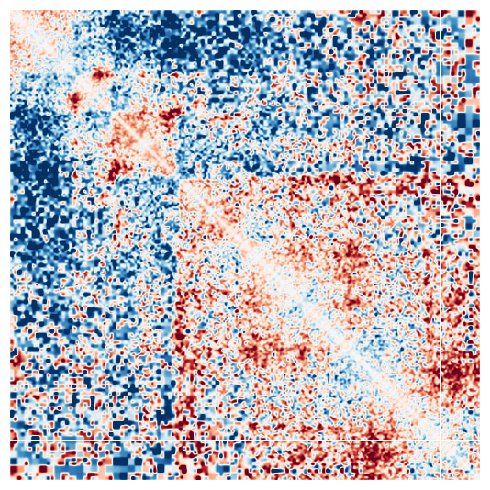

Seq 1 | Coordinates: chr11:66576384-67887104
num_filtered_bins: 9
Indices of rows with NaNs: [ 26  27  64  65 182 183 630 631 632]
num_filtered_bins: 9
Indices of rows with NaNs: [ 26  27  64  65 182 183 630 631 632]


/home1/smaruj/miniconda3/envs/pytorch_cuda11.8/lib/python3.12/site-packages/cooltools/lib/numutils.py:1376: RuntimeWarning: invalid value encountered in divide
  val_cur = ar_cur / armask_cur


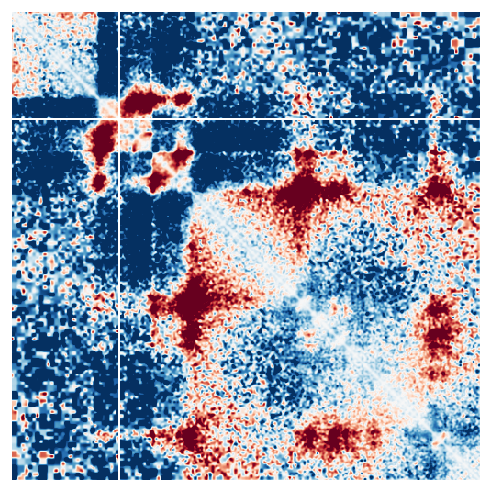

Seq 2 | Coordinates: chrX:57774080-59084800
num_filtered_bins: 24
Indices of rows with NaNs: [ 23 212 213 214 216 236 237 238 252 253 277 278 286 287 298 299 359 496
 497 499 500 532 533 557]
num_filtered_bins: 24
Indices of rows with NaNs: [ 23 212 213 214 216 236 237 238 252 253 277 278 286 287 298 299 359 496
 497 499 500 532 533 557]


/home1/smaruj/miniconda3/envs/pytorch_cuda11.8/lib/python3.12/site-packages/cooltools/lib/numutils.py:1376: RuntimeWarning: invalid value encountered in divide
  val_cur = ar_cur / armask_cur


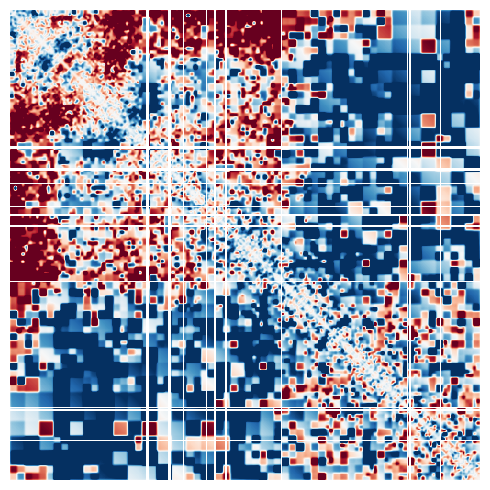

Seq 3 | Coordinates: chr11:67559424-68870144
num_filtered_bins: 3
Indices of rows with NaNs: [150 151 152]
num_filtered_bins: 3
Indices of rows with NaNs: [150 151 152]


/home1/smaruj/miniconda3/envs/pytorch_cuda11.8/lib/python3.12/site-packages/cooltools/lib/numutils.py:1376: RuntimeWarning: invalid value encountered in divide
  val_cur = ar_cur / armask_cur


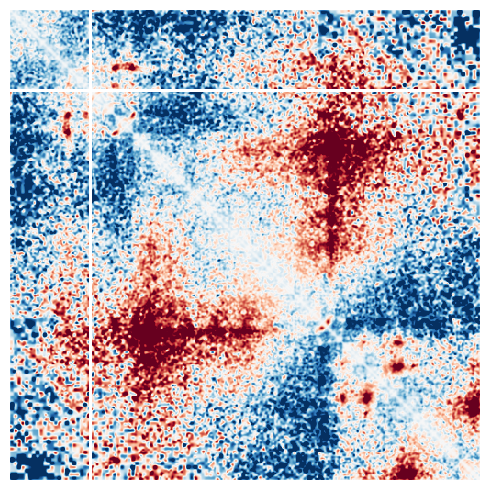

Seq 4 | Coordinates: chr3:100540416-101851136
num_filtered_bins: 0
Indices of rows with NaNs: []
num_filtered_bins: 0
Indices of rows with NaNs: []


/home1/smaruj/miniconda3/envs/pytorch_cuda11.8/lib/python3.12/site-packages/cooltools/lib/numutils.py:1376: RuntimeWarning: invalid value encountered in divide
  val_cur = ar_cur / armask_cur


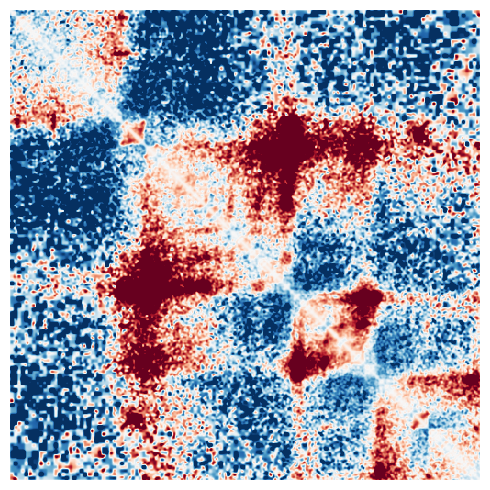

In [14]:
for i, row in enumerate(df_select_fold[-5:].itertuples(index=False)):
    chrom, start, end = row.chrom, row.start, row.end
    mseq_str = f"{chrom}:{start}-{end}"

    print(f"Seq {i} | Coordinates:", mseq_str)
    
    sequence = genome[chrom][start:end]
    ohe_sequence = one_hot_encode_sequence(sequence)
    # matrix = process_hic_matrix(genome_hic_cool, mseq_str, diagonal_offset=2, padding=32, sigma=1, width=5)
    
    matrix = process_hic_matrix(genome_hic_cool, mseq_str, diagonal_offset=2, padding=64, kernel_stddev=1, gaps_df=low_q_df)
    
    plot_map(matrix)
    
    # vector = upper_triangular_to_vector_skip_diagonals(matrix)
    
    # print(matrix.shape)
    # print(vector.shape)


    

In [ ]:
import re

def extract_coordinates_from_mseq(mseq_str):
    # Regular expression to match the format: chrom:start-end
    match = re.match(r"(?P<chrom>\w+):(?P<start>\d+)-(?P<end>\d+)", mseq_str)
    
    if match:
        chrom = match.group('chrom')
        start = int(match.group('start'))
        end = int(match.group('end'))
        return chrom, start, end
    else:
        raise ValueError(f"Invalid mseq_str format: {mseq_str}")

# Example usage
mseq_str = "chr1:1000000-2000000"
chrom, start, end = extract_coordinates_from_mseq(mseq_str)

print(f"Chromosome: {chrom}")
print(f"Start: {start}")
print(f"End: {end}")

In [ ]:
def generate_dataset(df, genome, genome_hic_cool):
    """
    Iterates through genomic regions, extracts DNA sequences and Hi-C matrices,
    and saves the data in a PyTorch-compatible format.

    Args:
        df (pd.DataFrame): DataFrame containing genomic regions
        genome (pyfaidx.Fasta): FASTA genome object
        genome_hic_cool (cooler.Cooler): Cooler object for Hi-C data

    Returns:
        list: List of (ohe_sequence, hic_matrix) tuples
    """
    data_list = []
    
    for row in df.itertuples(index=False):
        chrom, start, end = row.chrom, row.start, row.end
        mseq_str = f"{chrom}:{start}-{end}"
        
        # logging.info(f"Processing {mseq_str}")
        
        # One-hot encode sequence
        sequence = genome[chrom][start:end]
        ohe_sequence = one_hot_encode_sequence(sequence)

        # Process Hi-C matrix
        matrix = process_hic_matrix(genome_hic_cool, mseq_str, diagonal_offset=2, padding=32, sigma=1, width=5)

        # Convert to PyTorch tensors
        ohe_tensor = torch.tensor(ohe_sequence, dtype=torch.float32)  # Shape: (1, 4, seq_length)
        matrix_tensor = torch.tensor(matrix, dtype=torch.float32)  # Shape: (matrix_size, matrix_size)

        data_list.append((ohe_tensor, matrix_tensor))
    
    return data_list


In [ ]:
dataset = generate_dataset(df_train_fold[:5], genome, genome_hic_cool)

In [ ]:
for row in df_train_fold.itertuples(index=False):
    chrom, start, end = row.chrom, row.start, row.end - 262144   # difference between Akita.V1 and V2 window
    print(f"Processing {chrom}: {start}-{end}")
    
    mseq_str = '%s:%d-%d' % (chrom, start, end)
    
    sequence = genome[chrom][start:end]
    ohe_sequence = one_hot_encode_sequence(sequence)
    print(ohe_sequence.shape)
    
    matrix = process_hic_matrix(genome_hic_cool, mseq_str, diagonal_offset=2, padding=32, sigma=1, width=5)
    
    # Plot the matrix
    plt.figure(figsize=(8, 8))
    plt.matshow(matrix.astype(np.float16), cmap='RdBu_r', vmin=-0.6, vmax=0.6)
    plt.colorbar()
    plt.title('Heatmap of the Matrix')
    plt.show()
    

In [ ]:
import matplotlib.pyplot as plt

# Plot the matrix
plt.figure(figsize=(8, 8))
plt.matshow(kernel_log_hic_obsexp.astype(np.float16), cmap='RdBu_r', vmin=-0.6, vmax=0.6)
plt.colorbar()
plt.title('Heatmap of the Matrix')
plt.show()